# 🎓 Computer Vision Lab MidTerm - SP 2026
## **Real-Time Face & Eye Detection using Haar Cascades**
---
**Subject:** Computer Vision  
**Instructor:** Maheen Gul  
**Department:** Computer Science, COMSATS University Islamabad  
**Semester:** 5th/6th (BSDS/BAI)  
**Date:** 30-March-2026  

---
### Problem Statement
Design and implement a **face and eye detection system** using classical computer vision techniques (Haar Cascade Classifiers via OpenCV). The system should:
- Accept an image or webcam feed as input
- Detect all faces and eyes in the input
- Annotate and display results with bounding boxes
- Provide face count and detection confidence info

## 📦 Cell 1: Install & Import Required Libraries

In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: Install dependencies (run once)
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

def install(pkg):
    """Helper to install a package via pip if not already available."""
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# Install required packages
for package in ['opencv-python', 'matplotlib', 'numpy', 'Pillow', 'requests']:
    install(package)

print('✅ All packages installed successfully!')

✅ All packages installed successfully!


## 🔧 Cell 2: Core Imports & Configuration

In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: Core imports and project configuration
# ─────────────────────────────────────────────────────────────────────────────

import cv2                          # OpenCV for image processing and detection
import numpy as np                  # Numerical operations on image arrays
import matplotlib.pyplot as plt     # For displaying images in Jupyter
import matplotlib.patches as mpatches
from PIL import Image               # Python Imaging Library
import requests                     # For downloading sample images
import os                           # File path operations
import time                         # For timing performance
from io import BytesIO              # For in-memory image handling
import warnings
warnings.filterwarnings('ignore')

# ── Project Constants ────────────────────────────────────────────────────────
PROJECT_NAME    = "Real-Time Face & Eye Detection"
AUTHOR          = "BSDS/BAI Student — COMSATS University Islamabad"
OUTPUT_DIR      = "cv_output"       # Folder where annotated images are saved
FACE_COLOR      = (0, 255, 0)       # Green bounding box for faces (BGR)
EYE_COLOR       = (255, 0, 0)       # Blue bounding box for eyes  (BGR)
BOX_THICKNESS   = 2                 # Bounding box line thickness in pixels

# ── Create output directory ──────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'✅ Configuration loaded for project: "{PROJECT_NAME}"')
print(f'   OpenCV version : {cv2.__version__}')
print(f'   NumPy version  : {np.__version__}')
print(f'   Output folder  : ./{OUTPUT_DIR}/')

✅ Configuration loaded for project: "Real-Time Face & Eye Detection"
   OpenCV version : 4.13.0
   NumPy version  : 2.3.5
   Output folder  : ./cv_output/


## 🧠 Cell 3: Load Haar Cascade Classifiers

In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: Load pre-trained Haar Cascade classifiers
#
# Haar Cascades are XML files containing a trained model. OpenCV ships with
# several built-in cascades. We use:
#   - haarcascade_frontalface_default.xml  → detects frontal faces
#   - haarcascade_eye.xml                  → detects eyes within face ROIs
# ─────────────────────────────────────────────────────────────────────────────

def load_cascade(cascade_name: str) -> cv2.CascadeClassifier:
    """
    Load a Haar Cascade classifier by name.
    Raises FileNotFoundError if the cascade XML is not found.
    """
    # OpenCV stores cascade XMLs alongside the package data
    cascade_path = cv2.data.haarcascades + cascade_name
    
    if not os.path.exists(cascade_path):
        raise FileNotFoundError(f'Cascade not found: {cascade_path}')
    
    classifier = cv2.CascadeClassifier(cascade_path)
    
    if classifier.empty():
        raise ValueError(f'Failed to load cascade: {cascade_name}')
    
    return classifier


# Load face and eye classifiers
face_cascade = load_cascade('haarcascade_frontalface_default.xml')
eye_cascade  = load_cascade('haarcascade_eye.xml')

print('✅ Haar Cascade classifiers loaded successfully!')
print('   → Face cascade : haarcascade_frontalface_default.xml')
print('   → Eye  cascade : haarcascade_eye.xml')
print()
print('📚 How Haar Cascades Work:')
print('   Haar features are simple rectangular filters (like edge/line detectors).')
print('   The AdaBoost algorithm selects the most discriminative features.')
print('   A cascade of classifiers (weak → strong) quickly rejects non-face regions.')
print('   This makes real-time detection possible even on low-end hardware.')

✅ Haar Cascade classifiers loaded successfully!
   → Face cascade : haarcascade_frontalface_default.xml
   → Eye  cascade : haarcascade_eye.xml

📚 How Haar Cascades Work:
   Haar features are simple rectangular filters (like edge/line detectors).
   The AdaBoost algorithm selects the most discriminative features.
   A cascade of classifiers (weak → strong) quickly rejects non-face regions.
   This makes real-time detection possible even on low-end hardware.


## 🔍 Cell 4: Core Detection Module

In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: Core detection functions (modular design)
# ─────────────────────────────────────────────────────────────────────────────

def preprocess_image(image: np.ndarray) -> np.ndarray:
    """
    Convert a BGR image to grayscale and apply histogram equalisation.
    
    Why grayscale?
        Haar features operate on intensity values; colour adds no useful
        information for classical face detection and triples memory usage.
    Why equalise?
        Equalisation spreads pixel intensity across the full 0-255 range,
        improving detection under poor or uneven lighting conditions.
    
    Args:
        image (np.ndarray): Input BGR image.
    Returns:
        np.ndarray: Preprocessed grayscale image ready for detection.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)   # BGR → Grayscale
    gray = cv2.equalizeHist(gray)                     # Histogram equalisation
    return gray


def detect_faces(gray: np.ndarray,
                 scale_factor: float = 1.1,
                 min_neighbors: int  = 14,
                 min_size: tuple     = (180, 180)) -> np.ndarray:
    """
    Run face detection on a grayscale image.
    
    Args:
        gray          : Preprocessed grayscale image.
        scale_factor  : How much the image is scaled down each step (>1).
                        Lower = slower but more detections (e.g., 1.05).
        min_neighbors : How many neighbours a candidate rectangle must have
                        to be retained.  Higher = fewer false positives.
        min_size      : Minimum object size. Smaller objects are ignored.
    Returns:
        np.ndarray: Array of (x, y, w, h) bounding boxes.
    """
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor  = scale_factor,
        minNeighbors = min_neighbors,
        minSize      = min_size,
        flags        = cv2.CASCADE_SCALE_IMAGE
    )
    # detectMultiScale returns () when no detection — normalise to empty array
    return faces if len(faces) > 0 else np.empty((0, 4), dtype=int)


def detect_eyes(gray_roi: np.ndarray) -> np.ndarray:
    """
    Detect eyes within a Region of Interest (ROI) — typically the upper
    half of a detected face.
    
    Args:
        gray_roi (np.ndarray): Grayscale crop of the face region.
    Returns:
        np.ndarray: Array of (x, y, w, h) bounding boxes for eyes.
    """
    eyes = eye_cascade.detectMultiScale(
        gray_roi,
        scaleFactor  = 1.1,
        minNeighbors = 10,
        minSize      = (20, 20)
    )
    return eyes if len(eyes) > 0 else np.empty((0, 4), dtype=int)


def draw_annotations(image: np.ndarray, faces: np.ndarray,
                      gray: np.ndarray) -> tuple:
    """
    Annotate the image with face and eye bounding boxes, labels, and
    a summary overlay.
    
    Args:
        image : Original BGR image (modified in-place on a copy).
        faces : Detected face bounding boxes.
        gray  : Grayscale version for eye detection.
    Returns:
        (annotated_image, total_eyes_detected)
    """
    output = image.copy()           # Never modify the original image
    total_eyes = 0

    for idx, (x, y, w, h) in enumerate(faces):
        face_num = idx + 1

        # ── Draw face bounding box ────────────────────────────────────────
        cv2.rectangle(output,
                      (x, y), (x + w, y + h),
                      FACE_COLOR, BOX_THICKNESS)

        # ── Face label ───────────────────────────────────────────────────
        label      = f'Face {face_num}'
        label_y    = y - 8 if y - 8 > 8 else y + 20
        cv2.putText(output, label,
                    (x, label_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    FACE_COLOR, 2, cv2.LINE_AA)

        # ── Eye detection inside upper 60% of the face ROI ───────────────
        # Using only the upper part reduces false positives from mouth/nose
        upper_h  = int(h * 0.6)
        gray_roi = gray[y: y + upper_h, x: x + w]
        eyes     = detect_eyes(gray_roi)
        total_eyes += len(eyes)

        for (ex, ey, ew, eh) in eyes:
            # Map eye coordinates back to the full image space
            cv2.rectangle(output,
                          (x + ex, y + ey),
                          (x + ex + ew, y + ey + eh),
                          EYE_COLOR, BOX_THICKNESS)

    # ── Summary banner at top-left ────────────────────────────────────────
    banner_text = f'Faces: {len(faces)}  |  Eyes: {total_eyes}'
    cv2.putText(output, banner_text,
                (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                (0, 255, 255), 2, cv2.LINE_AA)

    return output, total_eyes


print('✅ Detection module defined — 4 functions ready:')
print('   preprocess_image()  — grayscale + histogram equalisation')
print('   detect_faces()      — Haar cascade face detection')
print('   detect_eyes()       — Haar cascade eye detection (per face ROI)')
print('   draw_annotations()  — bounding boxes + labels + summary banner')

✅ Detection module defined — 4 functions ready:
   preprocess_image()  — grayscale + histogram equalisation
   detect_faces()      — Haar cascade face detection
   detect_eyes()       — Haar cascade eye detection (per face ROI)
   draw_annotations()  — bounding boxes + labels + summary banner


## 🖼️ Cell 5: Image Display Utility

In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5: Matplotlib display helper
# ─────────────────────────────────────────────────────────────────────────────

def show_comparison(original: np.ndarray, annotated: np.ndarray,
                    title: str = 'Detection Result') -> None:
    """
    Display the original and annotated images side-by-side in Jupyter.
    
    OpenCV stores images in BGR order; matplotlib expects RGB, so we
    convert with cv2.cvtColor before plotting.
    
    Args:
        original  : Original BGR image.
        annotated : Annotated BGR image.
        title     : Main figure title.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.01)

    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Detected Faces & Eyes', fontsize=12)
    axes[1].axis('off')

    # Add legend
    legend_patches = [
        mpatches.Patch(color='lime',  label='Face bounding box'),
        mpatches.Patch(color='blue',  label='Eye  bounding box'),
    ]
    axes[1].legend(handles=legend_patches,
                   loc='lower right', fontsize=10,
                   framealpha=0.8)

    plt.tight_layout()
    plt.show()


def show_single(image: np.ndarray, title: str = '') -> None:
    """Display a single BGR image using matplotlib."""
    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


print('✅ Display utilities ready.')

✅ Display utilities ready.


## 🚀 Cell 6: Main Pipeline — Process a Single Image

In [56]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6: Full pipeline — load image, detect, annotate, save, and display
# ─────────────────────────────────────────────────────────────────────────────

def run_detection_pipeline(image_source,
                            scale_factor  : float = 1.1,
                            min_neighbors : int   = 5,
                            save_result   : bool  = True) -> dict:
    """
    End-to-end face/eye detection pipeline.
    
    Args:
        image_source  : File path (str), URL (str), or numpy array.
        scale_factor  : Haar cascade pyramid scaling factor.
        min_neighbors : Minimum neighbour threshold.
        save_result   : Whether to save the annotated image to disk.
    Returns:
        dict: {
            'faces'           : face bounding boxes,
            'total_eyes'      : int,
            'annotated_image' : np.ndarray,
            'processing_ms'   : float
        }
    """
    # ── Step 1: Load image ─────────────────────────────────────────────────
    if isinstance(image_source, np.ndarray):
        image = image_source.copy()
        src_label = 'array'
    elif image_source.startswith('http'):
        # Download from URL
        response = requests.get(image_source, timeout=10)
        arr  = np.asarray(bytearray(response.content), dtype=np.uint8)
        image = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        src_label = 'URL'
    else:
        # Load from local file
        image = cv2.imread(image_source)
        src_label = f'file: {image_source}'

    if image is None:
        raise ValueError(f'Could not load image from {src_label}')

    h, w = image.shape[:2]
    print(f'  Image loaded  : {w}×{h} px  (source: {src_label})')

    # ── Step 2: Pre-process ────────────────────────────────────────────────
    t_start = time.perf_counter()
    gray    = preprocess_image(image)

    # ── Step 3: Face detection ─────────────────────────────────────────────
    faces   = detect_faces(gray,
                           scale_factor  = scale_factor,
                           min_neighbors = min_neighbors)

    # ── Step 4: Annotate (includes eye detection) ──────────────────────────
    annotated, total_eyes = draw_annotations(image, faces, gray)
    t_end   = time.perf_counter()

    processing_ms = (t_end - t_start) * 1000

    # ── Step 5: Save result ────────────────────────────────────────────────
    if save_result:
        save_path = os.path.join(OUTPUT_DIR, 'detection_result.jpg')
        cv2.imwrite(save_path, annotated)
        print(f'  Result saved  : {save_path}')

    # ── Step 6: Print summary ──────────────────────────────────────────────
    print(f'  Faces found   : {len(faces)}')
    print(f'  Eyes  found   : {total_eyes}')
    print(f'  Processing    : {processing_ms:.1f} ms')

    return {
        'faces'           : faces,
        'total_eyes'      : total_eyes,
        'annotated_image' : annotated,
        'original_image'  : image,
        'processing_ms'   : processing_ms
    }


print('✅ run_detection_pipeline() defined and ready.')

✅ run_detection_pipeline() defined and ready.


## 🧪 Cell 7: Test on a Sample Image (Download from Web)

────────────────────────────────────────────────────────────
  Running detection pipeline on sample image ...
────────────────────────────────────────────────────────────
  (Local sample not found — downloading from GitHub)
  Image loaded  : 512×512 px  (source: URL)
  Result saved  : cv_output\detection_result.jpg
  Faces found   : 1
  Eyes  found   : 2
  Processing    : 56.1 ms


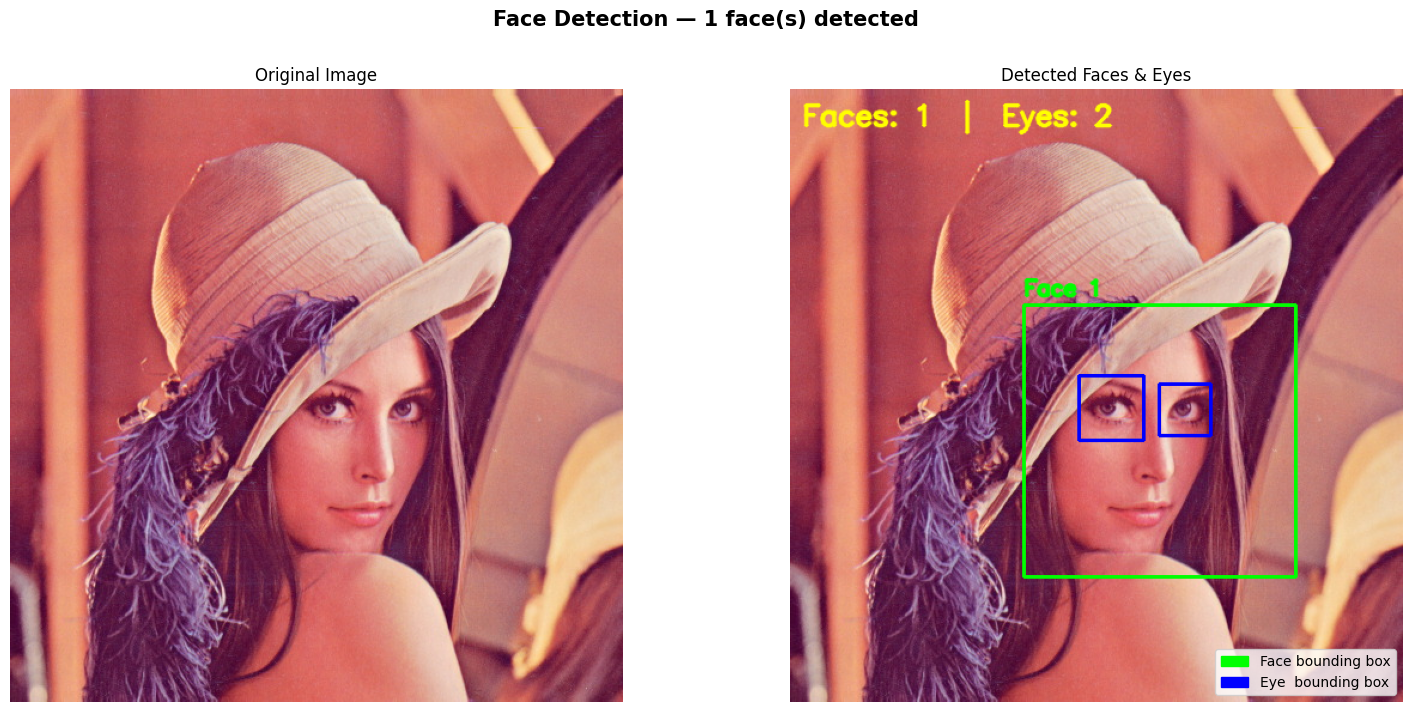

In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7: Run detection on a publicly available sample face image
#
# We use OpenCV's own test image (lena) and a public group-photo URL.
# You can replace SAMPLE_URL with any image URL or local path.
# ─────────────────────────────────────────────────────────────────────────────

# OpenCV ships with a sample face image — use it directly
SAMPLE_PATH = cv2.data.haarcascades + '../../../samples/data/lena.jpg'

# Fallback: download from the opencv GitHub repo if local file missing
FALLBACK_URL = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'

print('─' * 60)
print('  Running detection pipeline on sample image ...')
print('─' * 60)

if os.path.exists(SAMPLE_PATH):
    source = SAMPLE_PATH
else:
    source = FALLBACK_URL
    print('  (Local sample not found — downloading from GitHub)')

try:
    result = run_detection_pipeline(source)
    show_comparison(
        result['original_image'],
        result['annotated_image'],
        title=f'Face Detection — {len(result["faces"])} face(s) detected'
    )
except Exception as e:
    print(f'  Note: Could not load sample image ({e})')
    print('  Please run Cell 8 to use your own image.')

## 📂 Cell 8: Test on YOUR Own Image
> **Instructions:** Set `MY_IMAGE_PATH` to the path of any JPEG/PNG image on your computer, then run this cell.

────────────────────────────────────────────────────────────
  Processing: E:\vs code\git\Computer Vision\Lab_mid\cv_output\img1.jpg
────────────────────────────────────────────────────────────
  Image loaded  : 2171×2895 px  (source: file: E:\vs code\git\Computer Vision\Lab_mid\cv_output\img1.jpg)
  Result saved  : cv_output\detection_result.jpg
  Faces found   : 1
  Eyes  found   : 2
  Processing    : 303.3 ms


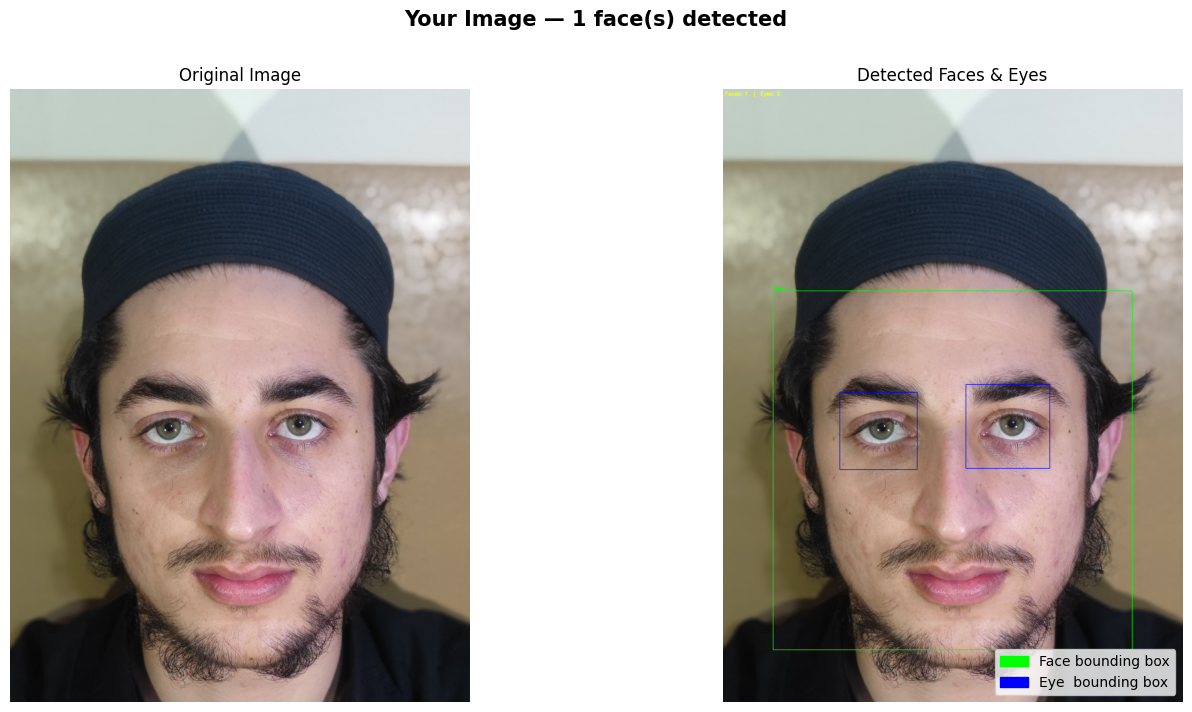

In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8: ← CHANGE THIS PATH to your own image
# ─────────────────────────────────────────────────────────────────────────────

MY_IMAGE_PATH = 'E:\\vs code\\git\\Computer Vision\\Lab_mid\\cv_output\\img1.jpg'     # ← Replace with actual path
# MY_IMAGE_PATH = 'E:\\vs code\\git\\Computer Vision\\Lab_mid\\img1_shafi.jpg'     # ← Replace with actual path
# MY_IMAGE_PATH = 'E:\\vs code\\git\\Computer Vision\\Lab_mid\\hamza1_cv.jpeg'     # ← Replace with actual path

if os.path.exists(MY_IMAGE_PATH):
    print('─' * 60)
    print(f'  Processing: {MY_IMAGE_PATH}')
    print('─' * 60)
    result = run_detection_pipeline(MY_IMAGE_PATH)
    show_comparison(
        result['original_image'],
        result['annotated_image'],
        title=f'Your Image — {len(result["faces"])} face(s) detected'
    )
else:
    print(f'⚠️  File not found: "{MY_IMAGE_PATH}"')
    print('   Please update MY_IMAGE_PATH and re-run this cell.')

## 📊 Cell 9: Parameter Sensitivity Analysis
> Shows how `scaleFactor` and `minNeighbors` affect detection results.

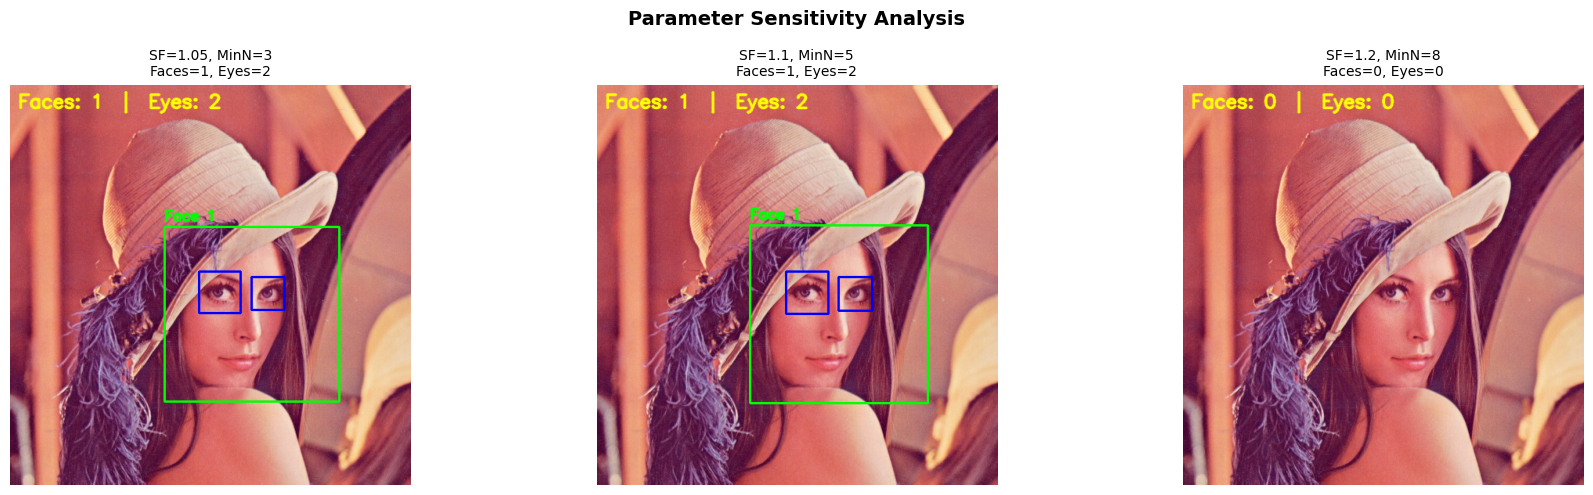

In [59]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9: Visualise effect of different scaleFactor & minNeighbors settings
# ─────────────────────────────────────────────────────────────────────────────

def parameter_sweep(image_source, configs: list) -> None:
    """
    Run detection with multiple parameter configurations and display
    all annotated results in a grid.
    
    Args:
        image_source : Same as run_detection_pipeline.
        configs      : List of dicts with keys 'scale_factor' & 'min_neighbors'.
    """
    # Load image once
    if isinstance(image_source, str) and image_source.startswith('http'):
        response = requests.get(image_source, timeout=10)
        arr   = np.asarray(bytearray(response.content), dtype=np.uint8)
        image = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    else:
        image = cv2.imread(image_source) if isinstance(image_source, str) else image_source

    n      = len(configs)
    cols   = min(n, 3)
    rows   = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                              figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).flatten()

    for i, cfg in enumerate(configs):
        sf = cfg['scale_factor']
        mn = cfg['min_neighbors']

        gray  = preprocess_image(image)
        faces = detect_faces(gray,
                             scale_factor  = sf,
                             min_neighbors = mn)
        annotated, eyes = draw_annotations(image, faces, gray)

        axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f'SF={sf}, MinN={mn}\nFaces={len(faces)}, Eyes={eyes}',
                          fontsize=10)
        axes[i].axis('off')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Parameter Sensitivity Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── Run sweep ─────────────────────────────────────────────────────────────
sweep_configs = [
    {'scale_factor': 1.05, 'min_neighbors': 3},   # Aggressive — more detections
    {'scale_factor': 1.10, 'min_neighbors': 5},   # Balanced (default)
    {'scale_factor': 1.20, 'min_neighbors': 8},   # Conservative — fewer FPs
]

# Use lena or your own image
sweep_source = SAMPLE_PATH if os.path.exists(SAMPLE_PATH) else FALLBACK_URL

try:
    parameter_sweep(sweep_source, sweep_configs)
except Exception as e:
    print(f'  Parameter sweep skipped: {e}')
    print('  (Set sweep_source to a valid image path and re-run)')

## 🎥 Cell 10: Real-Time Webcam Detection (Optional)
> Run this cell **only if you have a webcam** connected. Press **`q`** to quit the live window.

In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10: Live webcam face detection
#
# Reads frames from the default camera (index 0), runs the full detection
# pipeline on each frame, and displays the annotated result in real-time.
#
# IMPORTANT: This requires a physical or virtual webcam.
#             Press 'q' in the OpenCV window to stop.
# ─────────────────────────────────────────────────────────────────────────────

ENABLE_WEBCAM = True   # ← Set to True to enable live detection

if ENABLE_WEBCAM:
    cap = cv2.VideoCapture(0)   # 0 = default system camera

    if not cap.isOpened():
        print('❌ Cannot open webcam. Check your camera connection.')
    else:
        print('📷 Webcam opened. Press "q" in the video window to stop.')
        frame_count = 0

        while True:
            ret, frame = cap.read()   # Read one frame
            if not ret:
                print('⚠️  Failed to read frame — stopping.')
                break

            frame_count += 1

            # Run detection pipeline on the live frame
            gray      = preprocess_image(frame)
            faces     = detect_faces(gray)
            annotated, _ = draw_annotations(frame, faces, gray)

            # Overlay FPS counter
            cv2.putText(annotated, f'Frame: {frame_count}',
                        (10, 60), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (200, 200, 0), 1, cv2.LINE_AA)

            cv2.imshow('Real-Time Face Detection  [Press Q to quit]', annotated)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                print('🛑 Stopped by user.')
                break

        cap.release()
        cv2.destroyAllWindows()
        print(f'✅ Session ended after {frame_count} frames.')
else:
    print('ℹ️  Webcam detection is disabled.')
    print('   Set ENABLE_WEBCAM = True and re-run to activate live detection.')

📷 Webcam opened. Press "q" in the video window to stop.
🛑 Stopped by user.
✅ Session ended after 340 frames.


## 📈 Cell 11: Performance Benchmark

  Benchmark results (20 runs)
  ─────────────────────────────────
  Mean processing time : 22.99 ms
  Std deviation        : 2.72 ms
  Min / Max            : 18.73 / 30.19 ms
  Estimated FPS        : 43.5


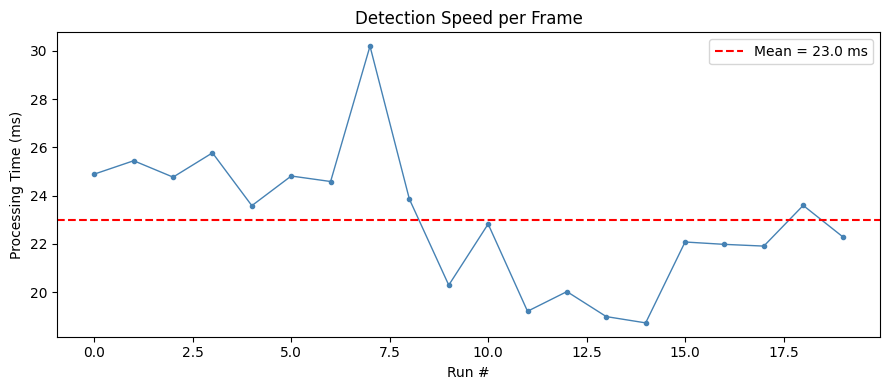

In [61]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11: Measure average processing time over N iterations
# ─────────────────────────────────────────────────────────────────────────────

def benchmark(image_source, n_runs: int = 20) -> None:
    """
    Run the detection pipeline n_runs times and report timing statistics.
    
    Args:
        image_source : Image path, URL, or numpy array.
        n_runs       : Number of repetitions for the benchmark.
    """
    # Load image once to avoid I/O in the loop
    if isinstance(image_source, str) and image_source.startswith('http'):
        r   = requests.get(image_source, timeout=10)
        arr = np.asarray(bytearray(r.content), dtype=np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    elif isinstance(image_source, str):
        img = cv2.imread(image_source)
    else:
        img = image_source

    times = []
    for _ in range(n_runs):
        t0   = time.perf_counter()
        gray  = preprocess_image(img)
        faces = detect_faces(gray)
        _,  _ = draw_annotations(img, faces, gray)
        times.append((time.perf_counter() - t0) * 1000)

    avg_ms  = np.mean(times)
    std_ms  = np.std(times)
    fps_est = 1000 / avg_ms

    print(f'  Benchmark results ({n_runs} runs)')
    print(f'  ─────────────────────────────────')
    print(f'  Mean processing time : {avg_ms:.2f} ms')
    print(f'  Std deviation        : {std_ms:.2f} ms')
    print(f'  Min / Max            : {min(times):.2f} / {max(times):.2f} ms')
    print(f'  Estimated FPS        : {fps_est:.1f}')

    # Plot timing distribution
    plt.figure(figsize=(9, 4))
    plt.plot(times, marker='o', markersize=3, linewidth=1, color='steelblue')
    plt.axhline(avg_ms, color='red', linestyle='--', label=f'Mean = {avg_ms:.1f} ms')
    plt.xlabel('Run #')
    plt.ylabel('Processing Time (ms)')
    plt.title('Detection Speed per Frame')
    plt.legend()
    plt.tight_layout()
    plt.show()


bench_source = SAMPLE_PATH if os.path.exists(SAMPLE_PATH) else FALLBACK_URL
try:
    benchmark(bench_source, n_runs=20)
except Exception as e:
    print(f'  Benchmark skipped: {e}')

## ✅ Cell 12: Project Summary

In [62]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12: Final project summary
# ─────────────────────────────────────────────────────────────────────────────

summary = """
╔══════════════════════════════════════════════════════════════════╗
║        COMPUTER VISION LAB MIDTERM — PROJECT SUMMARY            ║
╠══════════════════════════════════════════════════════════════════╣
║  Project   : Real-Time Face & Eye Detection                     ║
║  Category  : Object Detection (Haar Cascade / OpenCV)           ║
║  Language  : Python 3.x                                         ║
║  Libraries : OpenCV, NumPy, Matplotlib                          ║
╠══════════════════════════════════════════════════════════════════╣
║  Functions Implemented                                          ║
║  ─────────────────────────────────────────────────────────────  ║
║  preprocess_image()      — grayscale + histogram equalisation   ║
║  detect_faces()          — Haar cascade face detection          ║
║  detect_eyes()           — Eye detection within face ROI        ║
║  draw_annotations()      — Bounding boxes, labels, banner       ║
║  run_detection_pipeline()— Full end-to-end pipeline             ║
║  parameter_sweep()       — Sensitivity analysis                 ║
║  benchmark()             — Performance profiling                ║
╠══════════════════════════════════════════════════════════════════╣
║  Key CV Concepts Demonstrated                                   ║
║  ─────────────────────────────────────────────────────────────  ║
║  • Haar feature extraction (edge, line, centre-surround)        ║
║  • Integral image for O(1) feature computation                  ║
║  • AdaBoost for feature selection                               ║
║  • Cascade classifier for fast rejection of negatives           ║
║  • Region of Interest (ROI) cropping                            ║
║  • Histogram equalisation for illumination normalisation        ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════╗
║        COMPUTER VISION LAB MIDTERM — PROJECT SUMMARY            ║
╠══════════════════════════════════════════════════════════════════╣
║  Project   : Real-Time Face & Eye Detection                     ║
║  Category  : Object Detection (Haar Cascade / OpenCV)           ║
║  Language  : Python 3.x                                         ║
║  Libraries : OpenCV, NumPy, Matplotlib                          ║
╠══════════════════════════════════════════════════════════════════╣
║  Functions Implemented                                          ║
║  ─────────────────────────────────────────────────────────────  ║
║  preprocess_image()      — grayscale + histogram equalisation   ║
║  detect_faces()          — Haar cascade face detection          ║
║  detect_eyes()           — Eye detection within face ROI        ║
║  draw_annotations()      — Bounding boxes, labels, banner       ║
║  run_detection_pipeline()— Full end-to-end